In [1]:
# ----------------------------
# CNN PINN simulator
# ----------------------------

# Import necessary libraries
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
from scipy.ndimage import distance_transform_edt
import os
import time
import pandas as pd
import random

import os
import json
from pathlib import Path
import pyvista as pv
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", message="An output with one or more elements was resized")


In [2]:
# -------------------------------------------------------------
# Torch Device Configuration
# -------------------------------------------------------------
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU:", torch.cuda.get_device_name(0))
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Silicon GPU")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using Apple Silicon GPU


In [3]:
'''def compare_moose_vs_pinn(sim, data_dir, file_format: str = "parquet",
                           geometry_id: str = None, seed: int = None, save_path: str = None):
    """
    Picks one design (random, or a specific geometry_id), runs the PINN on
    its occupancy grid, and plots MOOSE vs PINN vs (PINN-MOOSE) for each of
    u, v, p, T. Prints and returns per-field error metrics.
 
    Args:
        sim: a PINN_Simulator instance (trained or not)
        data_dir: directory of .parquet/.pkl dataset files (same format
            build_dataset produces)
        file_format: "parquet" or "pickle"
        geometry_id: pick this specific design instead of a random one
            (matches the file's "hx_<geometry_id>" stem)
        seed: for reproducible random selection when geometry_id is None
        save_path: if given, also saves the figure there
 
    Returns:
        dict: {field_name: {'MAE':, 'RMSE':, 'max_abs_err':, 'rel_RMSE_%':}}
    """
    ext = ".parquet" if file_format == "parquet" else ".pkl"
    files = sorted(Path(data_dir).glob(f"*{ext}"))
    if not files:
        raise FileNotFoundError(f"no {ext} files found in {data_dir}")
 
    if geometry_id is not None:
        matches = [f for f in files if geometry_id in f.stem]
        if not matches:
            raise FileNotFoundError(f"no file matching geometry_id={geometry_id!r} in {data_dir}")
        path = matches[0]
    else:
        path = random.Random(seed).choice(files)
 
    df = pd.read_parquet(path) if file_format == "parquet" else pd.read_pickle(path)
    nx, ny = int(df["ix"].max()) + 1, int(df["iy"].max()) + 1
 
    def pivot(col):
        grid = np.full((ny, nx), np.nan, dtype=np.float32)
        grid[df["iy"].values, df["ix"].values] = df[col].values
        return grid
 
    occupancy = pivot("occupancy")  # 1=fluid, 0=solid
    fluid_mask = occupancy == 1
    moose = {name: pivot(name) for name in ["u", "v", "p", "T"]}
 
    # run the PINN on this design's occupancy grid
    occ_for_run = np.nan_to_num(occupancy, nan=0.0)
    pinn_pred = sim.run(occ_for_run)
 
    # --- numerical error metrics, fluid cells only ---
    metrics = {}
    for name in ["u", "v", "p", "T"]:
        gt = moose[name][fluid_mask]
        pr = pinn_pred[name][fluid_mask]
        diff = pr - gt
        mae = float(np.mean(np.abs(diff)))
        rmse = float(np.sqrt(np.mean(diff ** 2)))
        max_err = float(np.max(np.abs(diff)))
        gt_range = float(gt.max() - gt.min())
        rel_rmse_pct = 100.0 * rmse / gt_range if gt_range > 1e-12 else float("nan")
        metrics[name] = {"MAE": mae, "RMSE": rmse, "max_abs_err": max_err, "rel_RMSE_%": rel_rmse_pct}
 
    print(f"design: {path.stem}")
    print(f"{'field':6s} {'MAE':>12s} {'RMSE':>12s} {'max_abs_err':>14s} {'rel_RMSE_%':>12s}")
    for name, m in metrics.items():
        print(f"{name:6s} {m['MAE']:12.4e} {m['RMSE']:12.4e} {m['max_abs_err']:14.4e} {m['rel_RMSE_%']:12.2f}")
 
    # --- plot: rows = fields, columns = [MOOSE, PINN, difference] ---
    Lx, Ly = sim.domain_size
    extent = [0, Lx, 0, Ly]
    fig, axes = plt.subplots(4, 3, figsize=(15, 16))
 
    for row, name in enumerate(["u", "v", "p", "T"]):
        gt_masked = np.where(fluid_mask, moose[name], np.nan)
        pr_masked = np.where(fluid_mask, pinn_pred[name], np.nan)
        diff_masked = np.where(fluid_mask, pinn_pred[name] - moose[name], np.nan)
 
        # shared color scale between MOOSE and PINN panels so they're
        # visually comparable at a glance
        vmin = np.nanmin([np.nanmin(gt_masked), np.nanmin(pr_masked)])
        vmax = np.nanmax([np.nanmax(gt_masked), np.nanmax(pr_masked)])
 
        im0 = axes[row, 0].imshow(gt_masked, origin="lower", extent=extent, cmap="viridis", vmin=vmin, vmax=vmax)
        axes[row, 0].set_title(f"MOOSE {name}")
        fig.colorbar(im0, ax=axes[row, 0], fraction=0.046, pad=0.04)
 
        im1 = axes[row, 1].imshow(pr_masked, origin="lower", extent=extent, cmap="viridis", vmin=vmin, vmax=vmax)
        axes[row, 1].set_title(f"PINN {name}")
        fig.colorbar(im1, ax=axes[row, 1], fraction=0.046, pad=0.04)
 
        max_abs_diff = np.nanmax(np.abs(diff_masked))
        max_abs_diff = max_abs_diff if max_abs_diff > 1e-12 else 1.0
        im2 = axes[row, 2].imshow(diff_masked, origin="lower", extent=extent,
                                   cmap="RdBu_r", vmin=-max_abs_diff, vmax=max_abs_diff)
        axes[row, 2].set_title(f"PINN - MOOSE ({name})\nRMSE={metrics[name]['RMSE']:.3e}")
        fig.colorbar(im2, ax=axes[row, 2], fraction=0.046, pad=0.04)
 
        for ax in axes[row]:
            ax.set_xlabel("x [m]")
            ax.set_ylabel("y [m]")
            ax.set_aspect("equal")
 
    fig.suptitle(f"MOOSE vs PINN: {path.stem}", fontsize=14)
    fig.tight_layout()
 
    if save_path:
        fig.savefig(save_path, dpi=130, bbox_inches="tight")
        print(f"saved figure to {save_path}")
 
    plt.show()
 
    return metrics'''

'def compare_moose_vs_pinn(sim, data_dir, file_format: str = "parquet",\n                           geometry_id: str = None, seed: int = None, save_path: str = None):\n    """\n    Picks one design (random, or a specific geometry_id), runs the PINN on\n    its occupancy grid, and plots MOOSE vs PINN vs (PINN-MOOSE) for each of\n    u, v, p, T. Prints and returns per-field error metrics.\n\n    Args:\n        sim: a PINN_Simulator instance (trained or not)\n        data_dir: directory of .parquet/.pkl dataset files (same format\n            build_dataset produces)\n        file_format: "parquet" or "pickle"\n        geometry_id: pick this specific design instead of a random one\n            (matches the file\'s "hx_<geometry_id>" stem)\n        seed: for reproducible random selection when geometry_id is None\n        save_path: if given, also saves the figure there\n\n    Returns:\n        dict: {field_name: {\'MAE\':, \'RMSE\':, \'max_abs_err\':, \'rel_RMSE_%\':}}\n    """\n    ext = "

In [4]:
def compare_moose_vs_pinn(sim, data_dir, file_format: str = "parquet",
                           geometry_id: str = None, seed: int = None, save_path: str = None):
    """
    Picks one design (random, or a specific geometry_id), runs the PINN on
    its occupancy grid, and plots MOOSE vs PINN vs (PINN-MOOSE) for each of
    u, v, p, T -- all in NORMALIZED units (u/U_scale, v/U_scale, p/P_scale,
    (T-T_in)/T_scale), matching the scale the network is trained on.

    Args:
        sim: a PINN_Simulator instance (trained or not)
        data_dir: directory of .parquet/.pkl dataset files (same format
            build_dataset produces)
        file_format: "parquet" or "pickle"
        geometry_id: pick this specific design instead of a random one
            (matches the file's "hx_<geometry_id>" stem)
        seed: for reproducible random selection when geometry_id is None
        save_path: if given, also saves the figure there

    Returns:
        dict: {field_name: {'MAE':, 'RMSE':, 'max_abs_err':, 'rel_RMSE_%':}}
        (all in normalized units)
    """
    ext = ".parquet" if file_format == "parquet" else ".pkl"
    files = sorted(Path(data_dir).glob(f"*{ext}"))
    if not files:
        raise FileNotFoundError(f"no {ext} files found in {data_dir}")

    if geometry_id is not None:
        matches = [f for f in files if geometry_id in f.stem]
        if not matches:
            raise FileNotFoundError(f"no file matching geometry_id={geometry_id!r} in {data_dir}")
        path = matches[0]
    else:
        path = random.Random(seed).choice(files)

    df = pd.read_parquet(path) if file_format == "parquet" else pd.read_pickle(path)
    nx, ny = int(df["ix"].max()) + 1, int(df["iy"].max()) + 1

    def pivot(col):
        grid = np.full((ny, nx), np.nan, dtype=np.float32)
        grid[df["iy"].values, df["ix"].values] = df[col].values
        return grid

    occupancy = pivot("occupancy")  # 1=fluid, 0=solid
    fluid_mask = occupancy == 1
    moose_phys = {name: pivot(name) for name in ["u", "v", "p", "T"]}

    # run the PINN on this design's occupancy grid (physical-unit output,
    # since sim.run denormalizes internally)
    occ_for_run = np.nan_to_num(occupancy, nan=0.0)
    pinn_pred = sim.run(occ_for_run)

    # --- normalize both MOOSE ground truth and PINN output the same way
    # the network was trained: u_n = u/U_scale, v_n = v/U_scale,
    # p_n = p/P_scale, T_n = (T - T_in)/T_scale ---
    pl = sim.physics_loss
    scales = {"u": pl.U_scale, "v": pl.U_scale, "p": pl.P_scale, "T": pl.T_scale}
    shifts = {"u": 0.0, "v": 0.0, "p": 0.0, "T": pl.T_in}

    def normalize_field(name, arr):
        return (arr - shifts[name]) / scales[name]

    moose = {name: normalize_field(name, arr) for name, arr in moose_phys.items()}

    # --- numerical error metrics, fluid cells only (normalized units) ---
    metrics = {}
    for name in ["u", "v", "p", "T"]:
        gt = moose[name][fluid_mask]
        pr = pinn_pred[name][fluid_mask]
        diff = pr - gt
        mae = float(np.mean(np.abs(diff)))
        rmse = float(np.sqrt(np.mean(diff ** 2)))
        max_err = float(np.max(np.abs(diff)))
        gt_range = float(gt.max() - gt.min())
        rel_rmse_pct = 100.0 * rmse / gt_range if gt_range > 1e-12 else float("nan")
        metrics[name] = {"MAE": mae, "RMSE": rmse, "max_abs_err": max_err, "rel_RMSE_%": rel_rmse_pct}

    print(f"design: {path.stem}  (normalized units)")
    print(f"{'field':6s} {'MAE':>12s} {'RMSE':>12s} {'max_abs_err':>14s} {'rel_RMSE_%':>12s}")
    for name, m in metrics.items():
        print(f"{name:6s} {m['MAE']:12.4e} {m['RMSE']:12.4e} {m['max_abs_err']:14.4e} {m['rel_RMSE_%']:12.2f}")

    # --- plot: rows = fields, columns = [MOOSE, PINN, difference] ---
    Lx, Ly = sim.domain_size
    extent = [0, Lx, 0, Ly]
    fig, axes = plt.subplots(4, 3, figsize=(15, 16))

    field_labels = {"u": "u (norm.)", "v": "v (norm.)", "p": "p (norm.)", "T": "\u03b8 = (T-T_in)/\u0394T"}

    for row, name in enumerate(["u", "v", "p", "T"]):
        gt_masked = np.where(fluid_mask, moose[name], np.nan)
        pr_masked = np.where(fluid_mask, pinn_pred[name], np.nan)
        diff_masked = np.where(fluid_mask, pinn_pred[name] - moose[name], np.nan)

        # shared color scale between MOOSE and PINN panels so they're
        # visually comparable at a glance
        vmin = np.nanmin([np.nanmin(gt_masked), np.nanmin(pr_masked)])
        vmax = np.nanmax([np.nanmax(gt_masked), np.nanmax(pr_masked)])

        im0 = axes[row, 0].imshow(gt_masked, origin="lower", extent=extent, cmap="viridis", vmin=vmin, vmax=vmax)
        axes[row, 0].set_title(f"MOOSE {field_labels[name]}")
        fig.colorbar(im0, ax=axes[row, 0], fraction=0.046, pad=0.04)

        im1 = axes[row, 1].imshow(pr_masked, origin="lower", extent=extent, cmap="viridis", vmin=vmin, vmax=vmax)
        axes[row, 1].set_title(f"PINN {field_labels[name]}")
        fig.colorbar(im1, ax=axes[row, 1], fraction=0.046, pad=0.04)

        max_abs_diff = np.nanmax(np.abs(diff_masked))
        max_abs_diff = max_abs_diff if max_abs_diff > 1e-12 else 1.0
        im2 = axes[row, 2].imshow(diff_masked, origin="lower", extent=extent,
                                   cmap="RdBu_r", vmin=-max_abs_diff, vmax=max_abs_diff)
        axes[row, 2].set_title(f"PINN - MOOSE ({field_labels[name]})\nRMSE={metrics[name]['RMSE']:.3e}")
        fig.colorbar(im2, ax=axes[row, 2], fraction=0.046, pad=0.04)

        for ax in axes[row]:
            ax.set_xlabel("x [m]")
            ax.set_ylabel("y [m]")
            ax.set_aspect("equal")

    fig.suptitle(f"MOOSE vs PINN (normalized): {path.stem}", fontsize=14)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=130, bbox_inches="tight")
        print(f"saved figure to {save_path}")

    plt.show()

    return metrics

In [5]:
# ----------------------------
# CNN PINN Block Definitions
# ----------------------------

class ConvBlock(nn.Module):
        """Two 3x3 convs, each followed by GroupNorm + SiLU."""
        def __init__(self, in_ch, out_ch, groups=8):
            super().__init__()
            groups = min(groups, out_ch)
            self.net = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.GroupNorm(groups, out_ch),
                nn.SiLU(),
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.GroupNorm(groups, out_ch),
                nn.SiLU(),
            )
        
        def forward(self, x):
            return self.net(x)
    
class DownBlock(nn.Module):
    """Stride-2 conv downsample + ConvBlock.
    Learned (strided-conv) downsampling instead of max-pooling -- it preserves more boundary-layer detail,
    which matters for near-wall gradients that impact physics loss"""

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.down = nn.Conv2d(in_ch, in_ch, 4, stride=2, padding=1)
        self.block = ConvBlock(in_ch, out_ch)
    
    def forward(self, x):
        return self.block(self.down(x))

class UpBlock(nn.Module):
    """Transpose-conv upsample, concat skip connection, ConvBlock."""
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch, 4, stride=2, padding=1)
        self.block = ConvBlock(in_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            # guards against off-by-one size mismatches on odd input dims
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        return self.block(x)
    
# ----------------------------
# Spectral Convolution Layer for the bottleneck to solve pressure across the whole domain
# ----------------------------

class SpectralConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, modes_h, modes_w):
        super().__init__()
        self.out_ch = out_ch
        self.modes_h, self.modes_w = modes_h, modes_w
        scale = 1.0 / (in_ch * out_ch)
        # Real and imaginary parts stored as separate real-valued parameters,
        self.weight_real = nn.Parameter(scale * torch.randn(in_ch, out_ch, modes_h, modes_w))
        self.weight_imag = nn.Parameter(scale * torch.randn(in_ch, out_ch, modes_h, modes_w))
 
    def forward(self, x):
        B, C, H, W = x.shape
        x_ft = torch.fft.rfft2(x, norm="ortho")
        weight = torch.complex(self.weight_real, self.weight_imag)
        out_ft = torch.zeros(B, self.out_ch, H, W // 2 + 1, dtype=torch.cfloat, device=x.device)
        mh, mw = min(self.modes_h, H), min(self.modes_w, W // 2 + 1)
        out_ft[:, :, :mh, :mw] = torch.einsum("bixy,ioxy->boxy", x_ft[:, :, :mh, :mw], weight[:, :, :mh, :mw])
        return torch.fft.irfft2(out_ft, s=(H, W), norm="ortho")
    
class FNOBlock(nn.Module):
    """Fourier Neural Operator block. This is the bottleneck of the CNN PINN architecture."""
    def __init__(self, channels, modes_h=16, modes_w=16):
        super().__init__()
        self.spectral = SpectralConv2d(channels, channels, modes_h, modes_w)
        self.pointwise = nn.Conv2d(channels, channels, 1)
        self.norm = nn.GroupNorm(min(8, channels), channels)
        self.act = nn.SiLU()

    def forward(self, x):
        out = self.spectral(x) + self.pointwise(x)
        return self.act(self.norm(out))
        

In [6]:
class CNN_PINN(nn.Module):
    """
    U-Net encoder-deecoder with an FNO bottleneck.
    
    Input: (B, 4, H, W) -- occupancy, SDF, x-coord, y-coord
    Output: (B, 4, H, W) -- u, v, p, T (fluid region values only, masked in solid region)

    Sized for H=100, W = 200 (25x50 bottleneck, small enough for FFT-based spectral convs to be cheap)
    """
    def __init__(self, in_ch=4, base_ch=32, n_fno_blocks=4, fno_modes=16):
        super().__init__()

        self.stem = ConvBlock(in_ch, base_ch)               # H x   W
        self.down1 = DownBlock(base_ch, base_ch * 2)        # H/2 x W/2
        self.down2 = DownBlock(base_ch * 2, base_ch * 4)    # H/4 x W/4

        self.bottleneck = nn.Sequential(
            *[FNOBlock(base_ch * 4, fno_modes, fno_modes) for _ in range(n_fno_blocks)]
        )

        self.up2 = UpBlock(base_ch * 4, base_ch * 2, base_ch * 2)  # H/2 x W/2
        self.up1 = UpBlock(base_ch * 2, base_ch, base_ch)
        self.head = nn.Conv2d(base_ch, 4, kernel_size=1)  # u, v, p, T

    def forward(self, x):
        s0 = self.stem(x)
        s1 = self.down1(s0)
        s2 = self.down2(s1)
        b = self.bottleneck(s2)
        u2 = self.up2(b, s1)
        u1 = self.up1(u2, s0)
        out = self.head(u1)
        return out

In [7]:
class SpatialDerivative(nn.Module):
    """
    Calculates spatial derivative operators via fixed conv2d kernels using central difference approximations.
    Replicate-padded to get a valid derivative at the boundary. This is used to compute the physics loss for the PINN.
    """
    def __init__(self, dx: float, dy: float):
        super().__init__()
        assert abs(dx - dy) < 1e-9, "assumes square pixels (dx == dy)"
        self.h = dx
        
        ddx = torch.tensor([[0, 0, 0], [-1, 0, 1], [0, 0, 0]], dtype=torch.float32) / (2 * dx)
        ddy = torch.tensor([[0, -1, 0], [0, 0, 0], [0, 1, 0]], dtype=torch.float32) / (2 * dy)
        lap = torch.tensor([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=torch.float32) / (dx * dy)

        self.register_buffer("ddx", ddx.view(1, 1, 3, 3))
        self.register_buffer("ddy", ddy.view(1, 1, 3, 3))
        self.register_buffer("lap", lap.view(1, 1, 3, 3))

    def _conv_deriv(self, f, kernel):
        f = F.pad(f, (1, 1, 1, 1), mode="replicate")
        return F.conv2d(f, kernel)

    def d_dx(self, f):
        return self._conv_deriv(f, self.ddx)
    
    def d_dy(self, f):
        return self._conv_deriv(f, self.ddy)
    
    def laplacian(self, f):
        return self._conv_deriv(f, self.lap)

In [8]:
class PhysicsLoss(nn.Module):
    def __init__(self, fluid_properties: dict, boundary_conditions: dict,
                 domain_size=(2.0, 1.0), grid_shape=(200, 100)):
        super().__init__()
        W, H = grid_shape
        dx = domain_size[0] / W
        dy = domain_size[1] / H
        self.deriv = SpatialDerivative(dx, dy)

        self.rho = fluid_properties["rho"]
        self.mu = fluid_properties["mu"]
        self.k = fluid_properties["k"]
        self.cp = fluid_properties["cp"]
        self.nu = self.mu / self.rho
        self.alpha = self.k / (self.rho * self.cp)

        self.U_in = boundary_conditions["U_in"]
        self.T_in = boundary_conditions["T_in"]
        self.T_wall = boundary_conditions["T_wall"]
        self.P_pin = boundary_conditions["P_pin"]

        self.U_scale = self.U_in
        self.T_scale = self.T_wall - self.T_in
        self.P_scale = boundary_conditions["P_scale"]

        # normalized target values, precomputed once
        self.T_in_n = 0.0
        self.T_wall_n = 1.0

    def denormalize(self, pred_n):
        """pred_n: (B,4,H,W) normalized [u_n, v_n, p_n, T_n] -> physical [u,v,p,T]."""
        u_n, v_n, p_n, T_n = pred_n[:, 0:1], pred_n[:, 1:2], pred_n[:, 2:3], pred_n[:, 3:4]
        u = u_n * self.U_scale
        v = v_n * self.U_scale
        p = p_n * self.P_scale
        T = T_n * self.T_scale + self.T_in
        return u, v, p, T

    def dilate(self, mask, iterations=1):
        for _ in range(iterations):
            mask = F.pad(mask, (1, 1, 1, 1), mode="replicate")
            mask = F.max_pool2d(mask, kernel_size=3, stride=1, padding=0)
        return mask

    def erode(self, mask, iterations=1):
        return 1.0 - self.dilate(1.0 - mask, iterations=iterations)

    def masked_mse(self, field, target, mask):
        diff2 = (field - target) ** 2 * mask
        denom = mask.sum().clamp(min=1.0)
        return diff2.sum() / denom

    def forward(self, pred_n, occupancy):
        """
        pred_n: (B,4,H,W) NORMALIZED network output [u_n, v_n, p_n, T_n].
        occupancy: (B,1,H,W).
        """
        fluid = occupancy
        solid = 1 - occupancy

        # masks
        inlet_mask = torch.zeros_like(fluid)
        inlet_mask[:, :, :, 0] = fluid[:, :, :, 0]
        outlet_mask = torch.zeros_like(fluid)
        outlet_mask[:, :, :, -1] = fluid[:, :, :, -1]

        obstacle_wall = fluid * self.dilate(solid, iterations=1)
        edge_wall = torch.zeros_like(fluid)
        edge_wall[:, :, 0, :] = fluid[:, :, 0, :]
        edge_wall[:, :, -1, :] = fluid[:, :, -1, :]
        wall_band = torch.clamp(obstacle_wall + edge_wall, max=1.0)
        wall_band = wall_band * (1.0 - inlet_mask) * (1.0 - outlet_mask)

        interior = self.erode(fluid, iterations=1)

        # ---- Dirichlet/Neumann BC losses: computed directly in normalized space ----
        u_n, v_n, p_n, T_n = pred_n[:, 0:1], pred_n[:, 1:2], pred_n[:, 2:3], pred_n[:, 3:4]

        dun_dx = self.deriv.d_dx(u_n)
        dvn_dx = self.deriv.d_dx(v_n)
        dTn_dx = self.deriv.d_dx(T_n)

        inlet_loss = (
            self.masked_mse(u_n, 0.0, inlet_mask)
            + self.masked_mse(v_n, 0.0, inlet_mask)
            + self.masked_mse(T_n, self.T_in_n, inlet_mask)
        )
        outlet_loss = (
            self.masked_mse(dun_dx, 0.0, outlet_mask)
            + self.masked_mse(dvn_dx, 0.0, outlet_mask)
            + self.masked_mse(dTn_dx, 0.0, outlet_mask)
        )
        wall_loss = (
            self.masked_mse(u_n, 0.0, wall_band)
            + self.masked_mse(v_n, 0.0, wall_band)
            + self.masked_mse(T_n, self.T_wall_n, wall_band)
        )

        losses = {
            "bc_inlet": inlet_loss,
            "bc_outlet": outlet_loss,
            "bc_wall": wall_loss,
        }

        # ---- PDE residuals: need physical units, so denormalize first ----
        u, v, p, T = self.denormalize(pred_n)

        du_dx, du_dy = self.deriv.d_dx(u), self.deriv.d_dy(u)
        dv_dx, dv_dy = self.deriv.d_dx(v), self.deriv.d_dy(v)
        dp_dx, dp_dy = self.deriv.d_dx(p), self.deriv.d_dy(p)
        dT_dx, dT_dy = self.deriv.d_dx(T), self.deriv.d_dy(T)

        continuity = du_dx + dv_dy
        momentum_x = (u * du_dx + v * du_dy) + (1.0 / self.rho) * dp_dx - self.nu * self.deriv.laplacian(u)
        momentum_y = (u * dv_dx + v * dv_dy) + (1.0 / self.rho) * dp_dy - self.nu * self.deriv.laplacian(v)
        energy = (u * dT_dx + v * dT_dy) - self.alpha * self.deriv.laplacian(T)

        losses["pde_continuity"] = self.masked_mse(continuity, torch.zeros_like(continuity), interior)
        losses["pde_momentum_x"] = self.masked_mse(momentum_x, torch.zeros_like(momentum_x), interior)
        losses["pde_momentum_y"] = self.masked_mse(momentum_y, torch.zeros_like(momentum_y), interior)
        losses["pde_energy"] = self.masked_mse(energy, torch.zeros_like(energy), interior)

        return losses

In [9]:
def compute_sdf(occupancy: np.ndarray, dx: float, dy: float, domain_height: float) -> np.ndarray:
    """
    Physical-distance signed distance function: positive in fluid, negative
    in solid, normalized by domain_height. occupancy: 1=fluid, 0=solid.
    """
    fluid = occupancy == 1
    dist_to_solid = distance_transform_edt(fluid, sampling=(dy, dx))    # fluid px -> nearest solid px
    dist_to_fluid = distance_transform_edt(~fluid, sampling=(dy, dx))   # solid px -> nearest fluid px
    sdf = np.where(fluid, dist_to_solid, -dist_to_fluid)
    return (sdf / domain_height).astype(np.float32)
 
 
def compute_normalized_coords(nx: int, ny: int, dx: float, dy: float, domain_height: float):
    """Cell-center x, y coordinates, both normalized by domain_height (preserves aspect ratio)."""
    x = (np.arange(nx) + 0.5) * dx / domain_height
    y = (np.arange(ny) + 0.5) * dy / domain_height
    xx, yy = np.meshgrid(x, y)  # each (ny, nx)
    return xx.astype(np.float32), yy.astype(np.float32)
 
 
def build_input_tensor(occupancy_grid: np.ndarray, domain_size=(2.0, 1.0)) -> torch.Tensor:
    """
    Converts a binary occupancy grid (1=fluid, 0=solid) into the 4-channel
    network input tensor: [occupancy, sdf, x, y]. Matches build_dataset's
    normalization exactly (SDF and coords both / domain_height).
 
    Args:
        occupancy_grid: (H, W) array, 1=fluid, 0=solid
        domain_size: (Lx, Ly) physical domain size in meters
 
    Returns: (4, H, W) float32 tensor
    """
    occ = occupancy_grid.astype(np.float32)
    H, W = occ.shape
    Lx, Ly = domain_size
    dx, dy = Lx / W, Ly / H
 
    sdf = compute_sdf(occ, dx, dy, Ly)
    x_coords, y_coords = compute_normalized_coords(W, H, dx, dy, Ly)
 
    input_np = np.stack([occ, sdf, x_coords, y_coords], axis=0)
    return torch.from_numpy(input_np)

In [10]:
# ===========================================================================
# Dataset: reads parquet/pickle files from build_dataset, pivots each tidy
# per-cell dataframe back into 2D grids.
# ===========================================================================
 
class ParquetHeatExchangerDataset(Dataset):
    """
    Reads .parquet or .pkl files produced by build_dataset (pinn_simulator.py).
    Each file: tidy per-cell table with columns
    [geometry_id, ix, iy, occupancy, sdf, x, y, u, v, p, T].
 
    __getitem__ returns:
        input_tensor:  (4, H, W)  [occupancy, sdf, x, y]  -- read directly
                       from the cached columns, NOT recomputed
        target_tensor: (4, H, W)  [u, v, p, T], NaN in solid cells replaced
                       with 0.0 (NaN * 0-mask = NaN, not 0 -- must be
                       filled here, not left for the loss function)
        fluid_mask:    (1, H, W)  1=fluid, 0=solid (== occupancy channel)
    """
 
    def __init__(self, data_dir=None, file_format: str = "parquet", geometry_ids: list = None,
                 files: list = None):
        """
        Either pass data_dir (globs all files of file_format in that
        directory) or files (an explicit list of file paths) -- files
        takes precedence if both are given. The explicit-list path is what
        train_model uses for its train/val split.
        """
        self.file_format = file_format
 
        if files is not None:
            self.files = sorted(Path(f) for f in files)
        else:
            self.data_dir = Path(data_dir)
            ext = ".parquet" if file_format == "parquet" else ".pkl"
            self.files = sorted(self.data_dir.glob(f"*{ext}"))
            if geometry_ids is not None:
                wanted = set(geometry_ids)
                self.files = [f for f in self.files if f.stem.replace("hx_", "") in wanted]
 
        if not self.files:
            raise FileNotFoundError("no dataset files found (check data_dir/files/geometry_ids)")
 
    def __len__(self):
        return len(self.files)
 
    def _pivot(self, df, col, nx, ny):
        grid = np.full((ny, nx), np.nan, dtype=np.float32)
        grid[df["iy"].values, df["ix"].values] = df[col].values
        return grid
 
    def __getitem__(self, idx):
        path = self.files[idx]
        df = pd.read_parquet(path) if self.file_format == "parquet" else pd.read_pickle(path)
 
        nx, ny = int(df["ix"].max()) + 1, int(df["iy"].max()) + 1
 
        occupancy = self._pivot(df, "occupancy", nx, ny)
        sdf = self._pivot(df, "sdf", nx, ny)
        x = self._pivot(df, "x", nx, ny)
        y = self._pivot(df, "y", nx, ny)
        input_tensor = torch.from_numpy(np.stack([occupancy, sdf, x, y], axis=0))
 
        target_fields = []
        for col in ["u", "v", "p", "T"]:
            field = self._pivot(df, col, nx, ny)
            field = np.nan_to_num(field, nan=0.0)  # solid-cell NaN -> 0.0, see docstring
            target_fields.append(field)
        target_tensor = torch.from_numpy(np.stack(target_fields, axis=0))
 
        fluid_mask = torch.from_numpy(np.nan_to_num(occupancy, nan=0.0)).unsqueeze(0)
 
        return input_tensor, target_tensor, fluid_mask

class NormalizedDataset(Dataset):
    """
    Wraps a ParquetHeatExchangerDataset and normalizes the target fields
    [u, v, p, T] at load time:
        u_n = u / U_scale
        v_n = v / U_scale
        p_n = p / P_scale
        T_n = (T - T_in) / T_scale     where T_scale = T_wall - T_in

    input_tensor and fluid_mask pass through unchanged (inputs are already
    O(1): occupancy in {0,1}, sdf/x/y normalized by domain_height).
    """
    def __init__(self, base_dataset: Dataset, U_scale: float, P_scale: float,
                 T_in: float, T_scale: float):
        self.base = base_dataset
        self.register_scale = torch.tensor([U_scale, U_scale, P_scale, T_scale]).view(4, 1, 1)
        self.register_shift = torch.tensor([0.0, 0.0, 0.0, T_in]).view(4, 1, 1)

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        input_tensor, target_tensor, fluid_mask = self.base[idx]
        target_norm = (target_tensor - self.register_shift) / self.register_scale
        return input_tensor, target_norm, fluid_mask

In [11]:
# ===========================================================================
# PINN_Simulator
# ===========================================================================
 
class PINN_Simulator(nn.Module):
    def __init__(self, fluid_properties: dict, boundary_conditions: dict, weights: dict,
                 domain_size=(2.0, 1.0), grid_shape=(100, 200)):
        """
        grid_shape is (H, W) = (ny, nx). For a "200x100" design (200 cells
        in x, 100 in y), pass grid_shape=(100, 200) -- double check this
        against your actual data before training; getting H/W backwards
        breaks the square-pixel assumption silently.
        """
        super().__init__()
        self.fluid_properties = fluid_properties
        self.boundary_conditions = boundary_conditions
        self.domain_size = domain_size
        self.grid_shape = grid_shape
 
        self.model = CNN_PINN(in_ch=4, base_ch=32, n_fno_blocks=4, fno_modes=16)
        self.physics_loss = PhysicsLoss(fluid_properties, boundary_conditions, domain_size, grid_shape)
        self.weights = weights or {
            "data": 5.0,
            "pde_continuity": 1.0,
            "pde_momentum_x": 1.0,
            "pde_momentum_y": 1.0,
            "pde_energy": 3.0,
            "bc_inlet": 5.0,
            "bc_wall": 5.0,
            "bc_outlet": 1.0,
            "bc_pressure_pin": 1.0,
        }
 
    def forward(self, x):
        return self.model(x)
 
    def combine_losses(self, loss_dict: dict, weights: dict = None) -> torch.Tensor:
        weights = weights or self.weights
        total = 0.0
        for name, value in loss_dict.items():
            total = total + weights.get(name, 1.0) * value
        return total
 
    def load_dataset(self, data_dir: str = None, file_format: str = "parquet",
                      geometry_ids: list = None, files: list = None) -> Dataset:
        """Returns a ParquetHeatExchangerDataset over data_dir, or over an explicit file list."""
        return ParquetHeatExchangerDataset(data_dir, file_format=file_format,
                                            geometry_ids=geometry_ids, files=files)
 
    def run(self, occupancy_grid: np.ndarray, domain_size: tuple = None) -> dict:
        """
        Runs inference on a fresh occupancy grid (e.g. from the optimizer),
        not from the cached dataset.
 
        Args:
            occupancy_grid: (H, W) array, 1=fluid, 0=solid
            domain_size: defaults to self.domain_size
 
        Returns: {'u': (H,W), 'v': (H,W), 'p': (H,W), 'T': (H,W)} numpy
        arrays, with solid-region cells set to NaN.
        """
        domain_size = domain_size or self.domain_size
        self.model.eval()
        device = next(self.model.parameters()).device
 
        input_tensor = build_input_tensor(occupancy_grid, domain_size).unsqueeze(0).to(device)
        with torch.no_grad():
            output = self.model(input_tensor)
 
        output = output.squeeze(0).cpu().numpy()
        fluid_mask = occupancy_grid == 1
        return {name: np.where(fluid_mask, ch, np.nan) for name, ch in zip(["u", "v", "p", "T"], output)}
 
    def train_model(self, data_dir: str, checkpoint_dir: str, result_dir: str = None,
                     file_format: str = "parquet", validation_split: float = 0.2,
                     split_seed: int = 42, max_train_designs: int = None,
                     batch_size: int = 4, num_epochs: int = 100,
                     warmup_epochs: int = 10, ramp_epochs: int = 10, learning_rate: float = 1e-4,
                     device: str = "cpu", num_workers: int = 4):
        """
        Trains on pre-built dataset files under a single data_dir, splitting
        into train/validation internally.
 
        Split behavior:
            - All files are shuffled once using split_seed (fixed, so the
              split is identical every time you call this with the same
              data_dir/validation_split/split_seed -- important for
              comparing runs across a dataset-size sweep).
            - The first `validation_split` fraction becomes the validation
              set and is NEVER used for training, regardless of
              max_train_designs.
            - The remaining files form the training pool. If
              max_train_designs is set, only the first max_train_designs
              files from that pool (in the fixed shuffled order) are used.
              Because the order is fixed, a smaller max_train_designs is
              always a strict SUBSET of a larger one -- e.g. the 100
              designs used with max_train_designs=100 are exactly the
              first 100 of the 200 used with max_train_designs=200. This
              isolates "does more data help" from "did the data change."
 
        Args:
            data_dir: directory containing all dataset files (parquet/pickle).
            validation_split: fraction of files held out for validation
                (e.g. 0.2 -> 20% validation, 80% available for training).
            split_seed: fixes the shuffle so splits are reproducible and
                comparable across sweep runs.
            max_train_designs: cap on training set size (for the
                100/200/500/1000 sweep). None = use the full training pool
                (all files not held out for validation).
        """
        os.makedirs(checkpoint_dir, exist_ok=True)
        if result_dir:
            os.makedirs(result_dir, exist_ok=True)
 
        ext = ".parquet" if file_format == "parquet" else ".pkl"
        all_files = sorted(Path(data_dir).glob(f"*{ext}"))
        if not all_files:
            raise FileNotFoundError(f"no {ext} files found in {data_dir}")
 
        rng = np.random.default_rng(split_seed)
        shuffled = list(all_files)
        rng.shuffle(shuffled)
 
        n_val = int(round(len(shuffled) * validation_split))
        val_files = shuffled[:n_val]
        train_pool = shuffled[n_val:]
 
        if max_train_designs is not None:
            if max_train_designs > len(train_pool):
                print(f"warning: max_train_designs={max_train_designs} exceeds the training "
                      f"pool size ({len(train_pool)}); using all {len(train_pool)} available.")
            train_files = train_pool[:max_train_designs]
        else:
            train_files = train_pool
 
        print(f"dataset split: {len(all_files)} total -> {len(val_files)} validation, "
              f"{len(train_pool)} training pool, {len(train_files)} used for training "
              f"(split_seed={split_seed})")
 
        self.to(device)
 
        train_ds_raw = self.load_dataset(None, file_format=file_format, files=train_files)
        val_ds_raw = self.load_dataset(None, file_format=file_format, files=val_files)

        # compute pressure scale from raw training data only (not val, to avoid leakage)
        #P_scale = compute_pressure_scale(train_ds_raw)
        P_scale = 1.0
        print(f"computed P_scale = {P_scale:.6e}")

        U_scale = self.physics_loss.U_in
        T_in = self.physics_loss.T_in
        T_scale = self.physics_loss.T_wall - self.physics_loss.T_in

        train_ds = NormalizedDataset(train_ds_raw, U_scale, P_scale, T_in, T_scale)
        val_ds = NormalizedDataset(val_ds_raw, U_scale, P_scale, T_in, T_scale)

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
        val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

        optimizer = torch.optim.Adam(self.model.parameters(), lr=learning_rate)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

        # stash scales so PhysicsLoss / eval code can denormalize consistently
        self.physics_loss.P_scale = P_scale

        best_val_loss = float("inf")
 
        for epoch in range(num_epochs):
            t0 = time.time()
            physics_weight = 0.0 if epoch < warmup_epochs else min(1.0, (epoch - warmup_epochs) / max(ramp_epochs, 1))
 
            train_metrics = self._run_epoch(train_loader, optimizer, physics_weight, device, train=True)
            val_metrics = self._run_epoch(val_loader, optimizer, physics_weight, device, train=False)
            scheduler.step()
 
            print(f"epoch {epoch:4d} [physics_w={physics_weight:.2f}] "
                  f"train_total={train_metrics['total']:.4e}  val_total={val_metrics['total']:.4e}  "
                  f"val_data={val_metrics['data']:.4e}  ({time.time()-t0:.1f}s)")
 
            if val_metrics["data"] < best_val_loss:
                best_val_loss = val_metrics["data"]
                torch.save({
                    "epoch": epoch, "model_state_dict": self.model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(), "val_data_loss": best_val_loss,
                    "fluid_properties": self.fluid_properties, "boundary_conditions": self.boundary_conditions,
                }, os.path.join(checkpoint_dir, "best_model.pt"))
 
        return self
 
    def _run_epoch(self, loader, optimizer, physics_weight, device, train: bool):
        self.model.train(mode=train)
        totals = {}
        n_batches = 0

        for input_tensor, target_tensor, fluid_mask in loader:
            input_tensor = input_tensor.to(device)
            target_tensor = target_tensor.to(device)   # already normalized
            fluid_mask = fluid_mask.to(device)
            occupancy = input_tensor[:, 0:1]

            with torch.set_grad_enabled(train):
                pred = self.model(input_tensor)          # normalized output

                data_diff2 = (pred - target_tensor) ** 2 * fluid_mask
                data_loss = data_diff2.sum() / fluid_mask.sum().clamp(min=1.0)
                losses = {"data": data_loss}

                all_losses = self.physics_loss(pred, occupancy)  # expects normalized pred
                for k, v in all_losses.items():
                    if k.startswith("bc_"):
                        losses[k] = v
                    else:
                        losses[k] = physics_weight * v

                total_loss = self.combine_losses(losses)

            if train:
                optimizer.zero_grad()
                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                optimizer.step()

            for name, value in losses.items():
                totals[name] = totals.get(name, 0.0) + value.item()
            totals["total"] = totals.get("total", 0.0) + total_loss.item()
            n_batches += 1

        return {name: v / n_batches for name, v in totals.items()}
 

In [ ]:
pinn_sim = PINN_Simulator(
    fluid_properties={"rho": 1000.0, "mu": 1.0e-3, "k": 0.598, "cp": 4186.0},
    boundary_conditions={"U_in": 1.0e-4, "T_in": 300.0,  "T_wall": 400.0, "P_pin": 0.0, "P_scale": 1.0},
    weights={
            "data": 3.0,
            "pde_continuity": 1.0,
            "pde_momentum_x": 1.0,
            "pde_momentum_y": 1.0,
            "pde_energy": 3.0,
            "bc_inlet": 5.0,
            "bc_wall": 5.0,
            "bc_outlet": 1.0,
            "bc_pressure_pin": 1.0,
        },
    domain_size=(2.0, 1.0),
    grid_shape=(200, 100)
)

pinn_sim.train_model(
    data_dir="dataset",
    checkpoint_dir="checkpoints",
    result_dir="pinn_results",
    file_format="parquet",
    validation_split=0.2,
    batch_size=4,
    num_epochs=40,
    warmup_epochs=5,
    ramp_epochs=5,
    learning_rate=1e-4,
    device=device,
    num_workers=0,
    max_train_designs=801
)

dataset split: 1001 total -> 200 validation, 801 training pool, 801 used for training (split_seed=42)
computed P_scale = 1.000000e+00
epoch    0 [physics_w=0.00] train_total=2.9919e+01  val_total=8.0599e+00  val_data=2.4152e+00  (40.1s)
epoch    1 [physics_w=0.00] train_total=6.2957e+00  val_total=5.4176e+00  val_data=1.6615e+00  (36.6s)
epoch    2 [physics_w=0.00] train_total=4.3471e+00  val_total=4.6796e+00  val_data=1.4458e+00  (36.7s)
epoch    3 [physics_w=0.00] train_total=3.5059e+00  val_total=4.1083e+00  val_data=1.2713e+00  (36.7s)
epoch    4 [physics_w=0.00] train_total=2.9741e+00  val_total=3.8799e+00  val_data=1.2076e+00  (36.7s)
epoch    5 [physics_w=0.00] train_total=2.5821e+00  val_total=3.5841e+00  val_data=1.1135e+00  (36.7s)
epoch    6 [physics_w=0.20] train_total=2.3211e+00  val_total=3.6130e+00  val_data=1.1316e+00  (36.5s)
epoch    7 [physics_w=0.40] train_total=2.1266e+00  val_total=3.3993e+00  val_data=1.0569e+00  (36.3s)
epoch    8 [physics_w=0.60] train_total=1.

PINN_Simulator(
  (model): CNN_PINN(
    (stem): ConvBlock(
      (net): Sequential(
        (0): Conv2d(4, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): GroupNorm(8, 32, eps=1e-05, affine=True)
        (2): SiLU()
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): GroupNorm(8, 32, eps=1e-05, affine=True)
        (5): SiLU()
      )
    )
    (down1): DownBlock(
      (down): Conv2d(32, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (block): ConvBlock(
        (net): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): GroupNorm(8, 64, eps=1e-05, affine=True)
          (2): SiLU()
          (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): GroupNorm(8, 64, eps=1e-05, affine=True)
          (5): SiLU()
        )
      )
    )
    (down2): DownBlock(
      (down): Conv2d(64, 64, kernel_size=(4, 4), stride=(2, 2), padding=(

design: hx_200x100-0.010m-t0005  (normalized units)
field           MAE         RMSE    max_abs_err   rel_RMSE_%
u        1.2103e-01   3.4449e-01     7.8546e+00         1.88
v        2.1290e-01   1.4020e+00     2.2693e+01         3.19
p        1.4103e-02   2.4237e-02     4.1751e-01       291.49
T        6.1906e-02   8.8977e-02     7.6281e-01         7.07


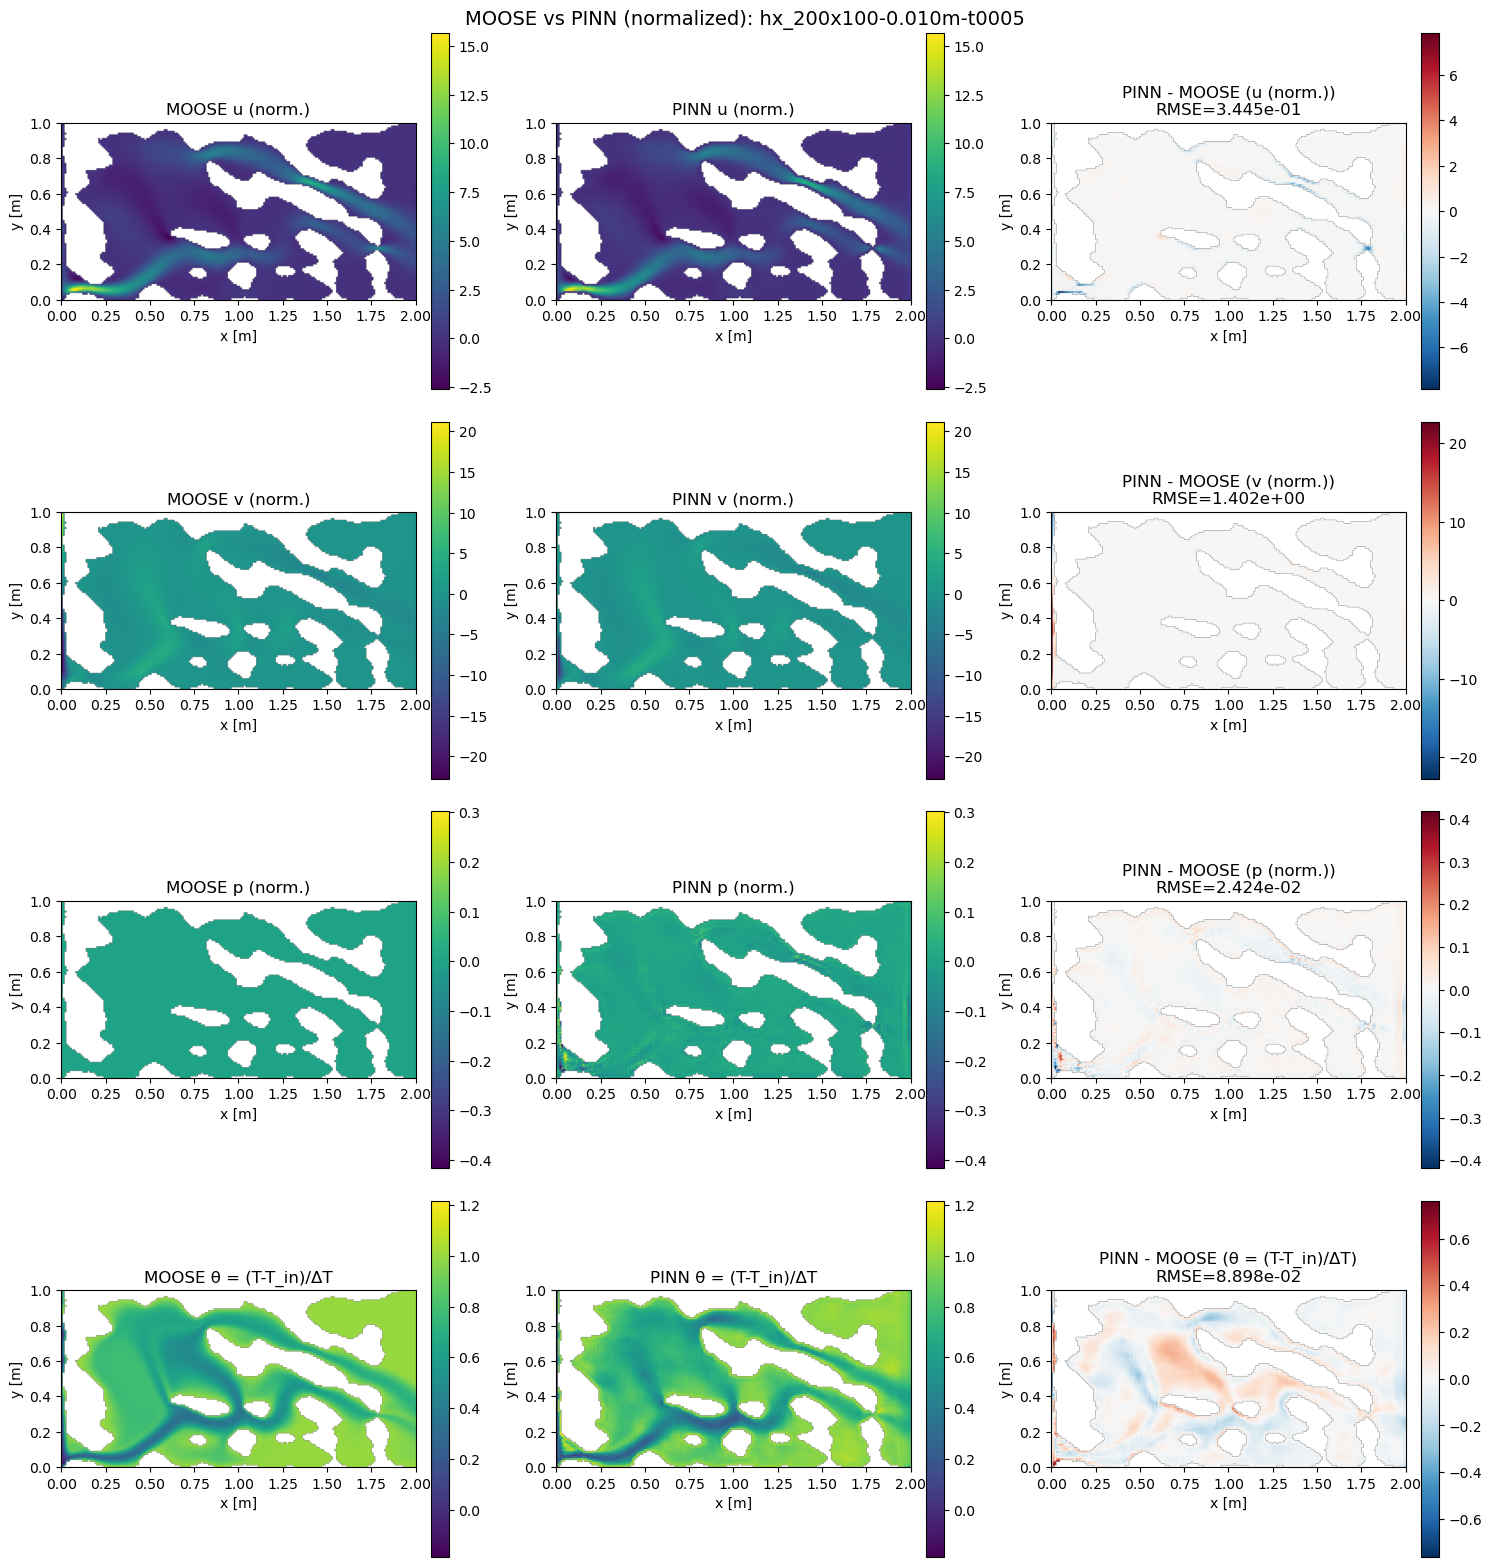

In [13]:
metrics = compare_moose_vs_pinn(sim=pinn_sim, data_dir="dataset", geometry_id="200x100-0.010m-t0005")